# Score, sensibilidad y forecasting acotado

## tl;dr

El baseline usa balance operativo simétrico y estabilidad de salidas, pero solo cuando existe actividad identificada suficiente en ambos sentidos. Las ventanas sin flujo, unilaterales o casi unilaterales conservan datos observados y reciben score nulo. En forecasting one-step sobre 761 series continuas, la media móvil de 3 meses obtiene la menor mediana de WAPE por serie (125,8 %), todavía insuficiente para prometer previsión precisa.

## Context & Methods

### Key Assumptions

- No hay target oficial: la evaluación del score es sensibilidad y coherencia, no accuracy.
- Cobertura temporal y suficiencia de señal financiera son dimensiones separadas.
- No se usan floors monetarios; el soporte mínimo es relativo e invariante a la escala de moneda.
- Las métricas agregadas de forecasting se normalizan dentro de cada serie sociedad/moneda antes de agregarse.
- El forecasting usa solo historia anterior a cada origen y exige 15 meses consecutivos.
- Las métricas se calculan por sociedad/moneda; no se mezclan divisas.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import pyarrow as pa

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "artifacts").is_dir())
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"blue": "#3568D4", "gold": "#C8942F", "orange": "#D96C2F", "charcoal": "#262B33"}

## Data

In [2]:
scores = pl.read_parquet(ROOT / "artifacts/score/scores.parquet")
sensitivity = pl.read_parquet(ROOT / "artifacts/score/sensitivity.parquet")
forecast_metrics = pl.read_parquet(ROOT / "artifacts/forecast/metrics.parquet")
forecast_currency_metrics = pl.read_parquet(ROOT / "artifacts/forecast/metrics_by_currency.parquet")
quality = scores.group_by("quality_status").agg(pl.len().alias("rows"), pl.col("score").is_null().sum().alias("null_scores")).sort("quality_status")
reasons = scores.filter(pl.col("score").is_null()).group_by("score_reason").len().sort("len", descending=True)
quality, reasons, forecast_metrics

(shape: (3, 3)
 ┌───────────────────┬───────┬─────────────┐
 │ quality_status    ┆ rows  ┆ null_scores │
 │ ---               ┆ ---   ┆ ---         │
 │ str               ┆ u32   ┆ u32         │
 ╞═══════════════════╪═══════╪═════════════╡
 │ available         ┆ 13826 ┆ 0           │
 │ insufficient_data ┆ 8505  ┆ 8505        │
 │ partial           ┆ 3930  ┆ 0           │
 └───────────────────┴───────┴─────────────┘,
 shape: (5, 2)
 ┌─────────────────────────────────┬──────┐
 │ score_reason                    ┆ len  │
 │ ---                             ┆ ---  │
 │ str                             ┆ u32  │
 ╞═════════════════════════════════╪══════╡
 │ insufficient_history            ┆ 3816 │
 │ one_sided_operating_activity    ┆ 2751 │
 │ imbalanced_operating_activity   ┆ 1287 │
 │ no_identified_operating_activi… ┆ 619  │
 │ missing_operating_flow_balance  ┆ 32   │
 └─────────────────────────────────┴──────┘,
 shape: (3, 7)
 ┌──────────────┬──────────┬──────────────┬──────────────┬──────

## Results

### Sensibilidad a pesos

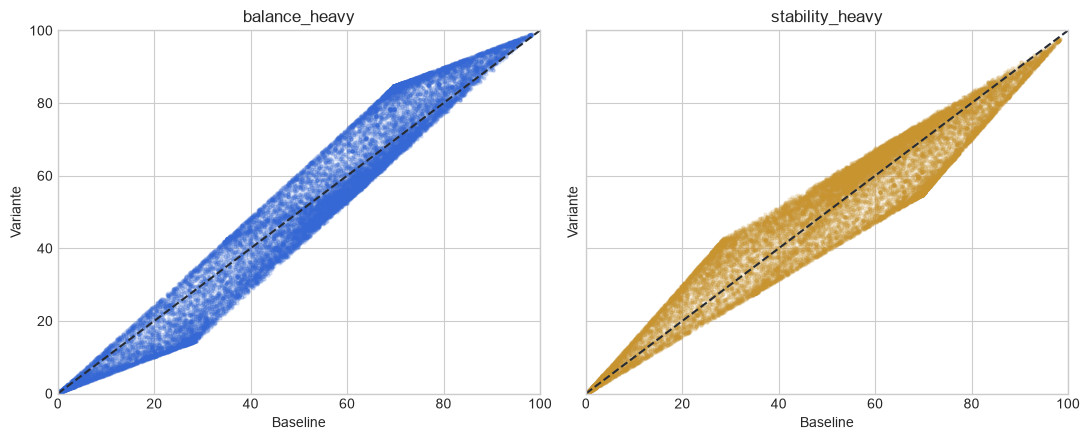

corr_balance,corr_stability,median_abs_diff_balance,median_abs_diff_stability
f64,f64,f64,f64
0.97255,0.958154,4.874613,4.874613


In [3]:
wide = sensitivity.filter(pl.col("score").is_not_null()).select("company_id", "month", "currency", "score_variant", "score").pivot(on="score_variant", index=["company_id", "month", "currency"], values="score")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for axis, variant, color in zip(axes, ["balance_heavy", "stability_heavy"], [COLORS["blue"], COLORS["gold"]]):
    axis.scatter(wide["baseline"].to_numpy(), wide[variant].to_numpy(), s=5, alpha=0.15, color=color)
    axis.plot([0, 100], [0, 100], color=COLORS["charcoal"], linestyle="--")
    axis.set(title=variant, xlabel="Baseline", ylabel="Variante", xlim=(0, 100), ylim=(0, 100))
plt.tight_layout()
plt.show()
wide.select(pl.corr("baseline", "balance_heavy").alias("corr_balance"), pl.corr("baseline", "stability_heavy").alias("corr_stability"), (pl.col("baseline")-pl.col("balance_heavy")).abs().median().alias("median_abs_diff_balance"), (pl.col("baseline")-pl.col("stability_heavy")).abs().median().alias("median_abs_diff_stability"))

### Forecasting one-step: 3 meses finales

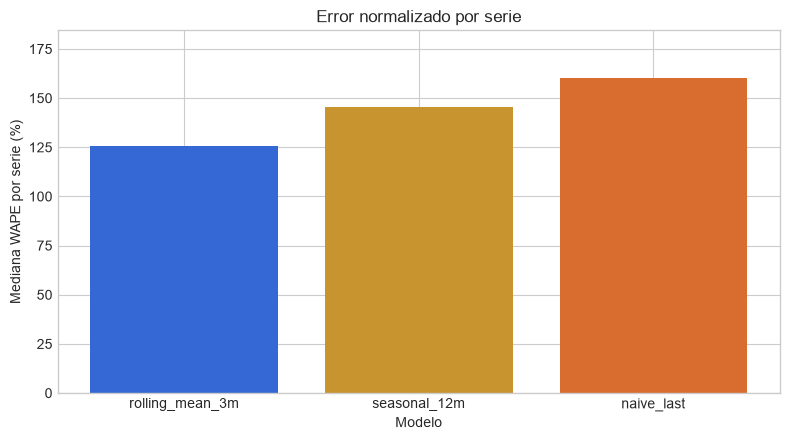

(shape: (3, 7)
 ┌──────────────┬──────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┐
 │ model        ┆ n_series ┆ n_prediction ┆ mean_series_ ┆ median_serie ┆ mean_series ┆ median_seri │
 │ ---          ┆ ---      ┆ s            ┆ wape         ┆ s_wape       ┆ _smape      ┆ es_smape    │
 │ str          ┆ u32      ┆ ---          ┆ ---          ┆ ---          ┆ ---         ┆ ---         │
 │              ┆          ┆ u32          ┆ f64          ┆ f64          ┆ f64         ┆ f64         │
 ╞══════════════╪══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╡
 │ rolling_mean ┆ 761      ┆ 2283         ┆ 22.681747    ┆ 1.258175     ┆ 1.387747    ┆ 1.421864    │
 │ _3m          ┆          ┆              ┆              ┆              ┆             ┆             │
 │ seasonal_12m ┆ 761      ┆ 2283         ┆ 739.299945   ┆ 1.456014     ┆ 1.525899    ┆ 1.561422    │
 │ naive_last   ┆ 761      ┆ 2283         ┆ 9.973292     ┆ 1.603482

In [4]:
metrics = forecast_metrics.sort("median_series_wape")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(metrics["model"].to_list(), metrics["median_series_wape"].to_numpy() * 100, color=[COLORS["blue"], COLORS["gold"], COLORS["orange"]])
ax.set(title="Error normalizado por serie", xlabel="Modelo", ylabel="Mediana WAPE por serie (%)")
ax.set_ylim(0, max(metrics["median_series_wape"].to_numpy() * 100) * 1.15)
plt.tight_layout()
plt.show()
metrics, forecast_currency_metrics.filter(pl.col("currency").is_in(["EUR", "USD", "GBP"])).sort("currency", "wape_within_currency")

## Takeaways

1. Recomendación: usar el score de dos pilares como baseline explicable provisional y exponer nivel, trayectoria, cobertura y suficiencia operativa.
2. No puntuar ventanas sin actividad bilateral identificable; la ausencia de salidas no es mala salud ni fortaleza.
3. No vender forecasting de flujo neto como validación de salud: el mejor baseline sigue teniendo error alto y cubre solo series continuas. MAE solo se interpreta dentro de cada moneda.
4. La siguiente decisión que más valor aporta es resolver dirección de facturas y target oficial, no añadir modelos complejos.